# Storytelling da EvoluÃ§Ã£o das Notas do ENEM

Bem-vindo a análise preditiva baseada nos dados do nosso **Data Lake (Camada Ouro)**.
Nestas visualizações, investigamos como o desempenho (médias de notas) dos candidatos nos Estados de todo o Brasil evoluiu ao longo do tempo.

In [1]:
# Instalando as bibliotecas essenciais para grÃ¡ficos (caso a sua imagem Docker nÃ£o as possua nativamente)
!pip install matplotlib seaborn pandas --quiet

In [2]:
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
spark = SparkSession.builder \
    .appName("StorytellingENEM") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/28 00:30:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [9]:
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Inicializa a sessÃ£o Spark no contexto do Jupyter
spark = SparkSession.builder \
    .appName("StorytellingENEM") \
    .getOrCreate()

# O caminho interno mapeado no container do Jupyter para a camada Ouro
pasta_ouro = "/app/data_lake/ouro/enem/media_notas_por_uf_ano"

# Lendo os dados jÃ¡ otimizados e agregados por UF e Ano do Parquet
try:
    df_ouro = spark.read.parquet(pasta_ouro)
    # Convertendo para Pandas para plotagem
    df_pd = df_ouro.toPandas()
    df_pd["ano"] = pd.to_numeric(df_pd["ano"])
    df_pd = df_pd.sort_values(by=["ano", "SG_UF_PROVA"])
    print("Dados da Camada Ouro (Média de Notas por UF) carregados com sucesso!")
    display(df_pd.head())
except Exception as e:
    print("¸ NÃ£o foi possÃ­vel carregar. Rode o pipeline Ouro antes.\n", e)
    df_pd = pd.DataFrame()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


Dados da Camada Ouro (Média de Notas por UF) carregados com sucesso!


,ano,SG_UF_PROVA,MEDIA_CN,MEDIA_CH,MEDIA_LC,MEDIA_MT,MEDIA_REDACAO
0,2020,AC,206.81,231.69,241.60,210.56,255.33
1,2020,AL,238.60,258.41,267.62,249.15,296.96
2,2020,AM,144.36,155.55,155.97,148.95,166.20
3,2020,AP,192.18,216.63,222.86,194.32,237.00
4,2020,BA,221.34,240.45,248.59,229.38,271.96


### Insight Visual 1: O Gap de Redação “ Cicatrizes no Ponto Máximo "

Enquanto a ansiedade tomou conta e muitas ausências se verificaram no ano de 2020, o desempenho literáio de argumentação foi um termometro sobre como o Brasil retomou as metodologias de estudo. A curva mostra o descolamento geográfico e as recuperação das médias de Redação.

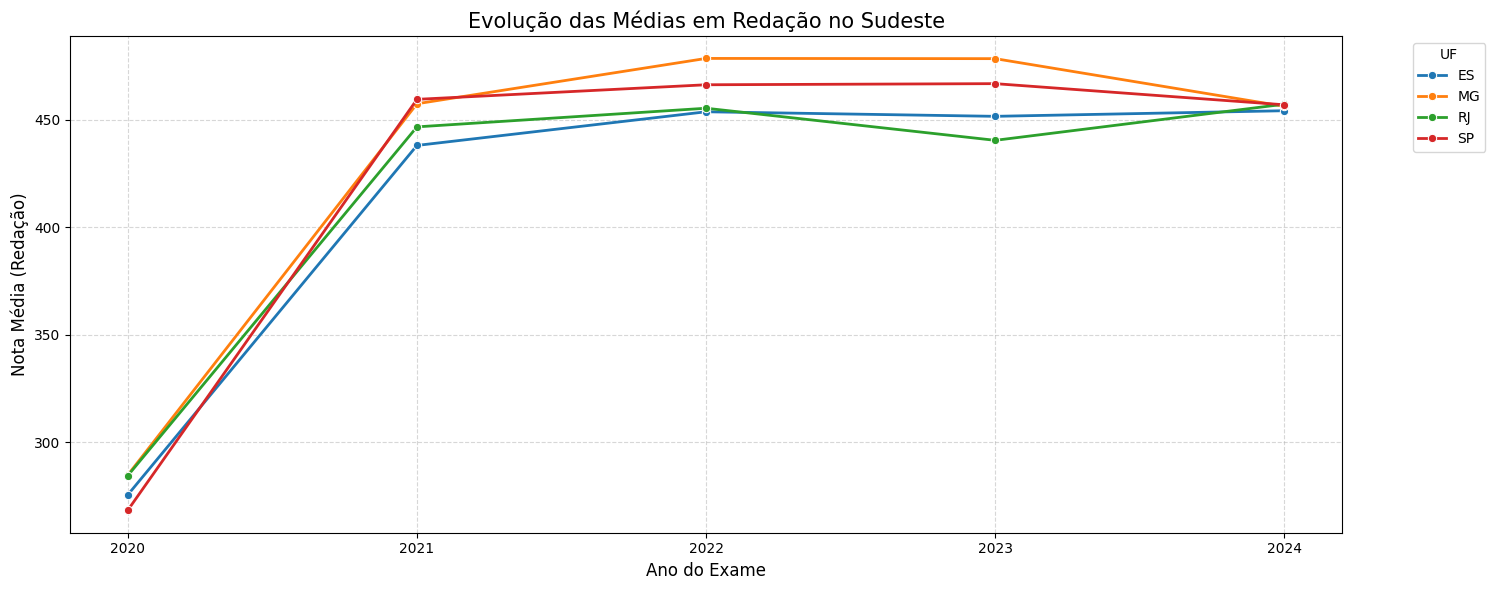

In [15]:
if not df_pd.empty and "MEDIA_REDACAO" in df_pd.columns:
    plt.figure(figsize=(15, 6))
    # Filtramos apenas as UFs do Sudeste para nÃ£o poluir o grÃ¡fico
    ufs_destaque = ["SP", "RJ", "MG", "ES"]
    df_plot = df_pd[df_pd["SG_UF_PROVA"].isin(ufs_destaque)]

    sns.lineplot(
        data=df_plot,
        x="ano",
        y="MEDIA_REDACAO",
        hue="SG_UF_PROVA",
        marker="o",
        linewidth=2
    )
    plt.title("EvoluÃ§Ã£o das MÃ©dias em RedaÃ§Ã£o no Sudeste", fontsize=15)
    plt.xlabel("Ano do Exame", fontsize=12)
    plt.ylabel("Nota MÃ©dia (RedaÃ§Ã£o)", fontsize=12)
    plt.xticks(df_plot["ano"].unique())
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(title="UF", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

### Insight Visual 2: Matemática Estagnada ou Recuperada?

Historicamente, a prova de ensino de Exatas tem fortes oscilações estruturais (falta de capacitação profissional/vagas de professores no país inteiro). Veja quem oscilou mais neste perído através de um comparativo visual barra-a-barra por Região.

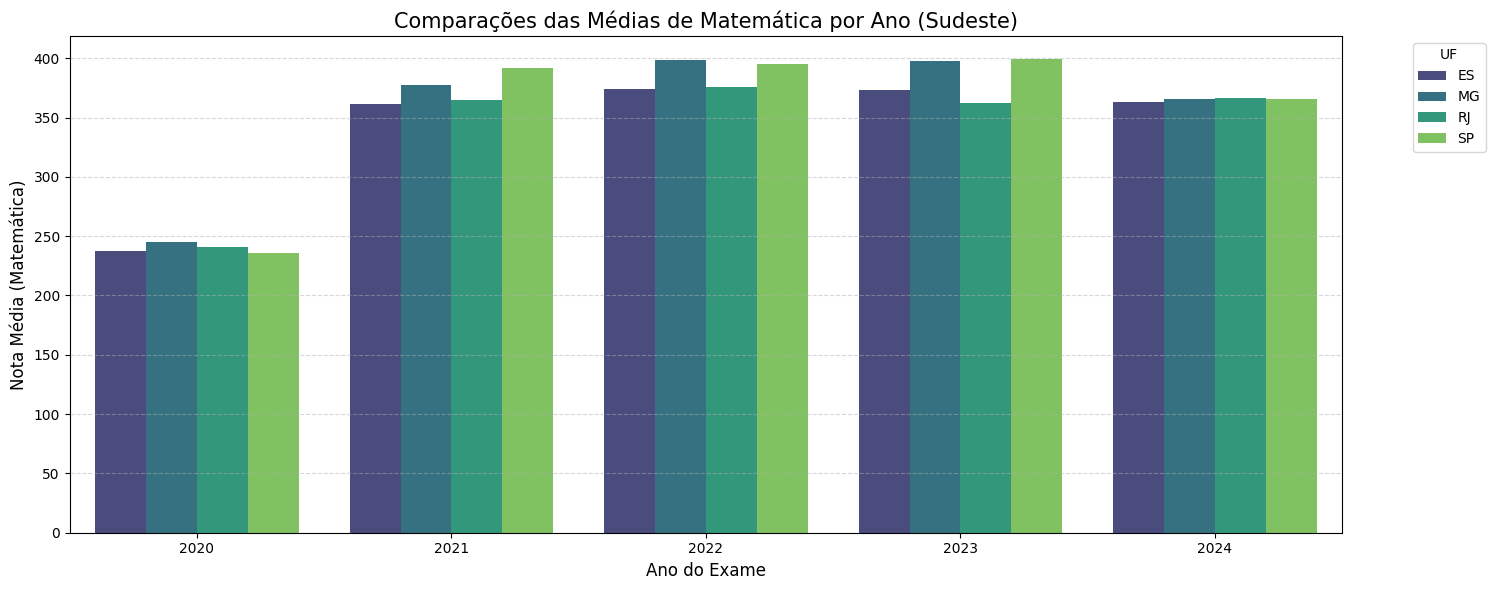

In [16]:
if not df_pd.empty and "MEDIA_MT" in df_pd.columns:
    plt.figure(figsize=(15, 6))
    ufs_destaque = ["SP", "RJ", "MG", "ES"]
    df_plot = df_pd[df_pd["SG_UF_PROVA"].isin(ufs_destaque)]

    sns.barplot(
        data=df_plot,
        x="ano",
        y="MEDIA_MT",
        hue="SG_UF_PROVA",
        palette="viridis"
    )
    plt.title("ComparaÃ§Ãµes das MÃ©dias de MatemÃ¡tica por Ano (Sudeste)", fontsize=15)
    plt.xlabel("Ano do Exame", fontsize=12)
    plt.ylabel("Nota MÃ©dia (MatemÃ¡tica)", fontsize=12)
    plt.legend(title="UF", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

### Insight Visual 3: O Retorno Maciço (Volume das Inscrições Validadas nas Provas)

As altas estatística de abstenções nos privaram de ver o mar de estudantes no ENEM em 2020 e 2021. Observar se as regiões consolidaram o retorno das provas , agrupando o engajamento e a constância do volume nos exames que fecharam o período.

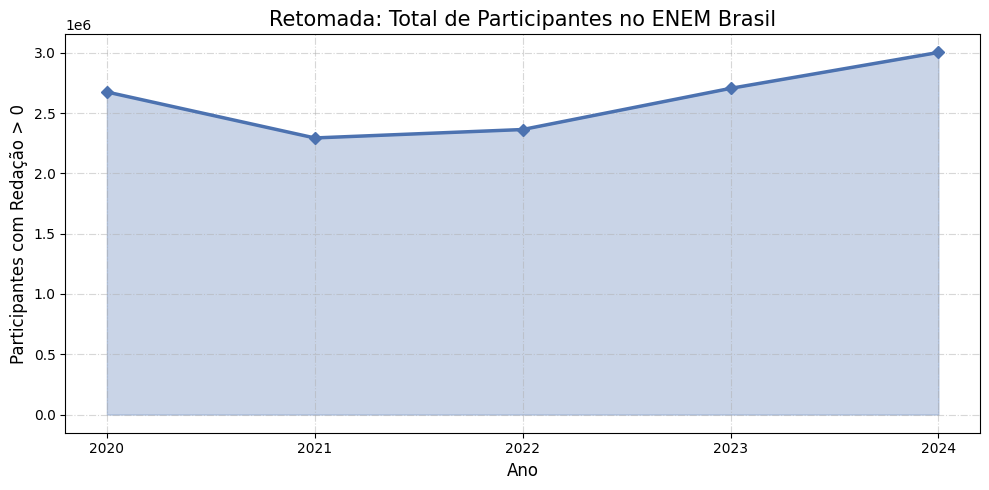

In [17]:
# Lendo base de Rankings da Camada Ouro para ver os Participantes por Ano
pasta_ranking = "/app/data_lake/ouro/enem/ranking_redacao_por_uf"
try:
    df_rk = spark.read.parquet(pasta_ranking).toPandas()
    df_rk["ano"] = pd.to_numeric(df_rk["ano"])
    df_total_ano = df_rk.groupby("ano")["TOTAL_PARTICIPANTES"].sum().reset_index()
    
    plt.figure(figsize=(10, 5))
    plt.fill_between(df_total_ano["ano"], df_total_ano["TOTAL_PARTICIPANTES"], color="#4C72B0", alpha=0.3)
    plt.plot(df_total_ano["ano"], df_total_ano["TOTAL_PARTICIPANTES"], color="#4C72B0", marker="D", linewidth=2.5)
    
    plt.title("Retomada: Total de Participantes no ENEM Brasil", fontsize=15)
    plt.xlabel("Ano", fontsize=12)
    plt.ylabel("Participantes com RedaÃ§Ã£o > 0", fontsize=12)
    plt.xticks(df_total_ano["ano"].unique())
    plt.grid(True, linestyle="-.", alpha=0.5)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Falha ao carregar ranking da camada Ouro:", e)

### Insight Visual 4: O Top 10 Estados na Redação

A tabela `ranking_redacao_por_uf` da Camada Ouro permite visualizar facilmente o ranking de excelÃªncia entre os estados. Vamos observar o Top 10 de maior mÃ©dia em redaÃ§Ã£o do ano mais recente presente no Data Lake.

/tmp/ipykernel_23/411672849.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top10, x="MEDIA_REDACAO", y="SG_UF_PROVA", palette="mako")


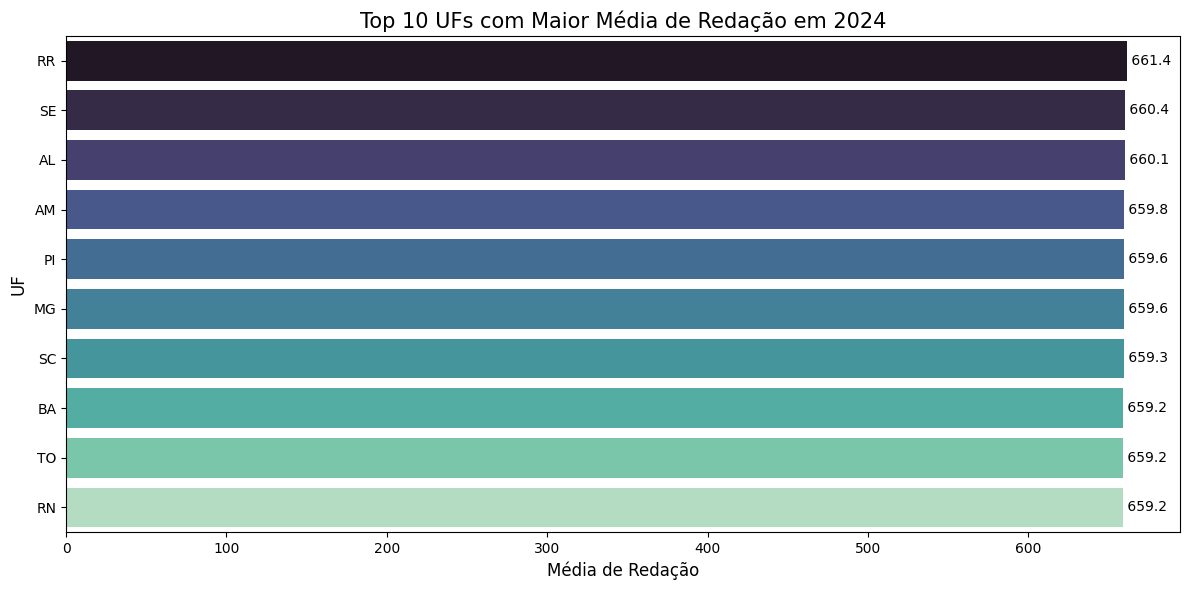

In [8]:
pasta_ranking = "/app/data_lake/ouro/enem/ranking_redacao_por_uf"
try:
    # Utilizando o df_rk jÃ¡ carregado ou recarregando
    if 'df_rk' not in locals():
        df_rk = spark.read.parquet(pasta_ranking).toPandas()
        df_rk["ano"] = pd.to_numeric(df_rk["ano"])
    
    ultimo_ano = df_rk["ano"].max()
    df_top10 = df_rk[df_rk["ano"] == ultimo_ano].sort_values(by="MEDIA_REDACAO", ascending=False).head(10)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_top10, x="MEDIA_REDACAO", y="SG_UF_PROVA", palette="mako")
    
    plt.title(f"Top 10 UFs com Maior Média de Redação em {ultimo_ano}", fontsize=15)
    plt.xlabel("Média de Redação", fontsize=12)
    plt.ylabel("UF", fontsize=12)
    for index, value in enumerate(df_top10['MEDIA_REDACAO']):
        plt.text(value, index, f" {value:.1f}", va='center')
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Falha ao plotar ranking Top 10:", e)


In [12]:
# Encerramos a sessÃ£o Spark de forma segura ao final da anÃ¡lise no Jupyter.
spark.stop()
